In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import helper

In [43]:
# @title LogReg from scratch (BCE)
class LogisticRegressionScratchBCE:
    def __init__(self, learning_rate=0.01, num_iterations=1000):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.w = None
        self.b = None
        self.losses = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def predict(self, X):
        z = np.dot(X, self.w) + self.b
        probs = self.sigmoid(z)

        # Return the class with the highest probability
        return np.where(probs >= 0.5, 1, 0)
    
    def predict_proba(self, X):
        z = np.dot(X, self.w) + self.b
        probs = self.sigmoid(z)
        return probs

    def initialize_weights(self, n_features):
        self.w = np.zeros((n_features, 1))  # Init with the same column number as feature
        self.b = 0

    def cost_function(self, h, y):
        m = len(y)
        # reg_term = (0.01 / (2 * m)) * np.sum(self.w ** 2)
        cost = -(1 / m) * np.sum(y * np.log(h + 1e-8) + (1 - y) * np.log(1 - h + 1e-8))

        return cost #+ reg_term

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y).reshape(-1, 1)  # Ensure y is a column vector
        print(X.shape, y.shape)
        m = len(y)
        n_features = X.shape[1]
        self.initialize_weights(n_features)

        for i in range(self.num_iterations):
            # Forward propagation
            probs = self.predict_proba(X)   # ← FIXED

            # Cost
            error = self.cost_function(probs, y)
            self.losses.append(error)

            # Gradients
            gradient_w = (1 / m) * np.dot(X.T, (probs - y))
            gradient_b = (1 / m) * np.sum(probs - y)

            # Update
            self.w -= self.learning_rate * gradient_w
            self.b -= self.learning_rate * gradient_b

            if i % 100 == 0:
                print(f"Iteration {i}, Cost: {error}")

    def plot_loss(self):
        plt.figure(figsize=(8, 5))
        plt.plot(range(self.num_iterations), self.losses, label='MSE Loss')
        plt.xlabel("Iteration")
        plt.ylabel("Loss (MSE)")
        plt.title("Loss Curve: Logistic Regression (BCE)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [44]:
df = helper.prepare_data()

In [45]:
# X is all pay amount
# X = df[['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']]
X = df[['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']]
y = df['default.payment.next.month']

In [13]:
X.head()

,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
1,0,2,0,0,0,2,0.0,1000.0,1000.0,1000.0,0.0,2000.0
2,0,0,0,0,0,0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0
3,0,0,0,0,0,0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0
4,0,0,0,0,0,0,2000.0,36681.0,10000.0,9000.0,689.0,679.0
5,0,0,0,0,0,0,2500.0,1815.0,657.0,1000.0,1000.0,800.0


In [46]:
X,y = SMOTE(random_state=42).fit_resample(X, y)
scaler = StandardScaler()
X = scaler.fit_transform(X)

Accuracy: 0.7055223219231195
Confusion Matrix:


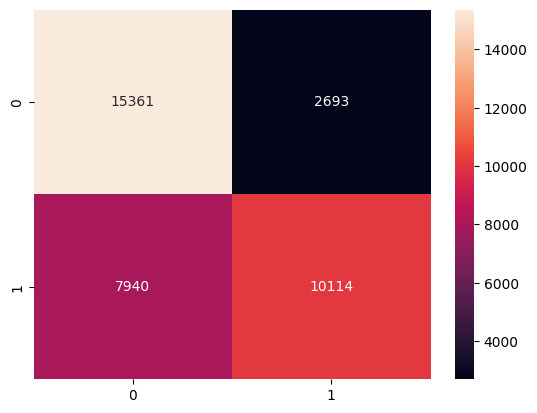

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.85      0.74     18054
           1       0.79      0.56      0.66     18054

    accuracy                           0.71     36108
   macro avg       0.72      0.71      0.70     36108
weighted avg       0.72      0.71      0.70     36108



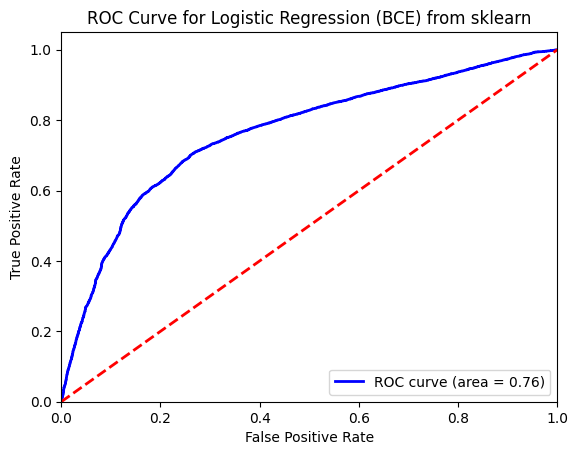

In [47]:
# import and use logistic regression bce from sklearn
model = LogisticRegression(solver='lbfgs')
model.fit(X, y)
y_pred = model.predict(X)
y_pred_proba = model.predict_proba(X)[:, 1]
helper.evaluate_model(y, y_pred)
helper.plot_roc_curve(y, y_pred_proba, title="Logistic Regression (BCE) from sklearn")


(36108, 12) (36108, 1)
Iteration 0, Cost: 0.6931471605599453
Accuracy: 0.6906502714079982
Confusion Matrix:


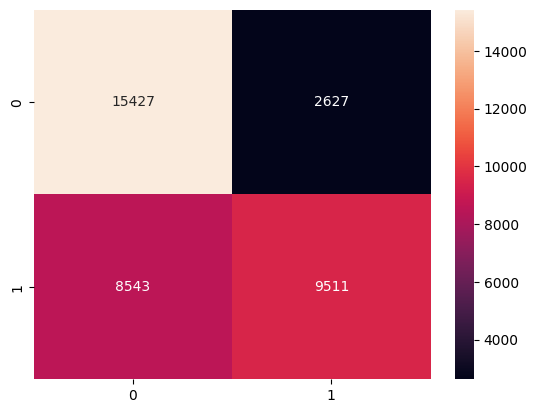

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.85      0.73     18054
           1       0.78      0.53      0.63     18054

    accuracy                           0.69     36108
   macro avg       0.71      0.69      0.68     36108
weighted avg       0.71      0.69      0.68     36108



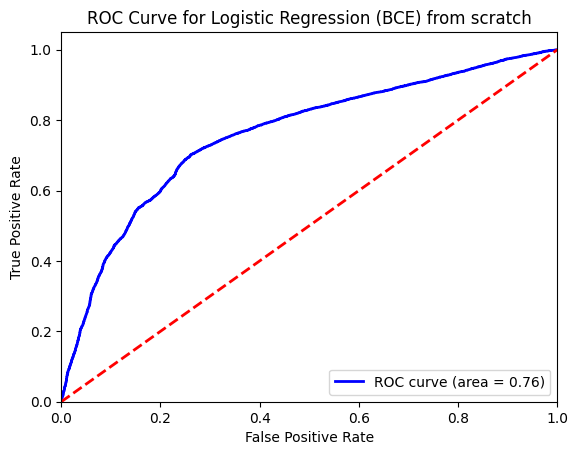

In [48]:
bce_model = LogisticRegressionScratchBCE(learning_rate=0.01, num_iterations=100)
bce_model.fit(X, y)
y_pred_bce = bce_model.predict(X)
y_pred_proba_bce = bce_model.predict_proba(X)
helper.evaluate_model(y, y_pred_bce)
helper.plot_roc_curve(y, y_pred_proba_bce, title="Logistic Regression (BCE) from scratch")